
--- Stage 1/4: Training on original data ---
Epoch 1/25, Train Loss: 0.065962, Val Loss: 0.029067
Epoch 2/25, Train Loss: 0.026896, Val Loss: 0.023592
Epoch 3/25, Train Loss: 0.022888, Val Loss: 0.021409
Epoch 4/25, Train Loss: 0.021085, Val Loss: 0.020940
Epoch 5/25, Train Loss: 0.019127, Val Loss: 0.018005
Epoch 6/25, Train Loss: 0.016922, Val Loss: 0.016283
Epoch 7/25, Train Loss: 0.014901, Val Loss: 0.014307
Epoch 8/25, Train Loss: 0.014952, Val Loss: 0.015047
Epoch 9/25, Train Loss: 0.014433, Val Loss: 0.013826
Epoch 10/25, Train Loss: 0.013460, Val Loss: 0.012021
Epoch 11/25, Train Loss: 0.012938, Val Loss: 0.012748
Epoch 12/25, Train Loss: 0.013680, Val Loss: 0.012593
Epoch 13/25, Train Loss: 0.012417, Val Loss: 0.013275
Epoch 14/25, Train Loss: 0.012367, Val Loss: 0.012547
Epoch 15/25, Train Loss: 0.012823, Val Loss: 0.012012
Epoch 16/25, Train Loss: 0.012478, Val Loss: 0.012263
Epoch 17/25, Train Loss: 0.012418, Val Loss: 0.011248
Epoch 18/25, Train Loss: 0.012612, Val Loss: 

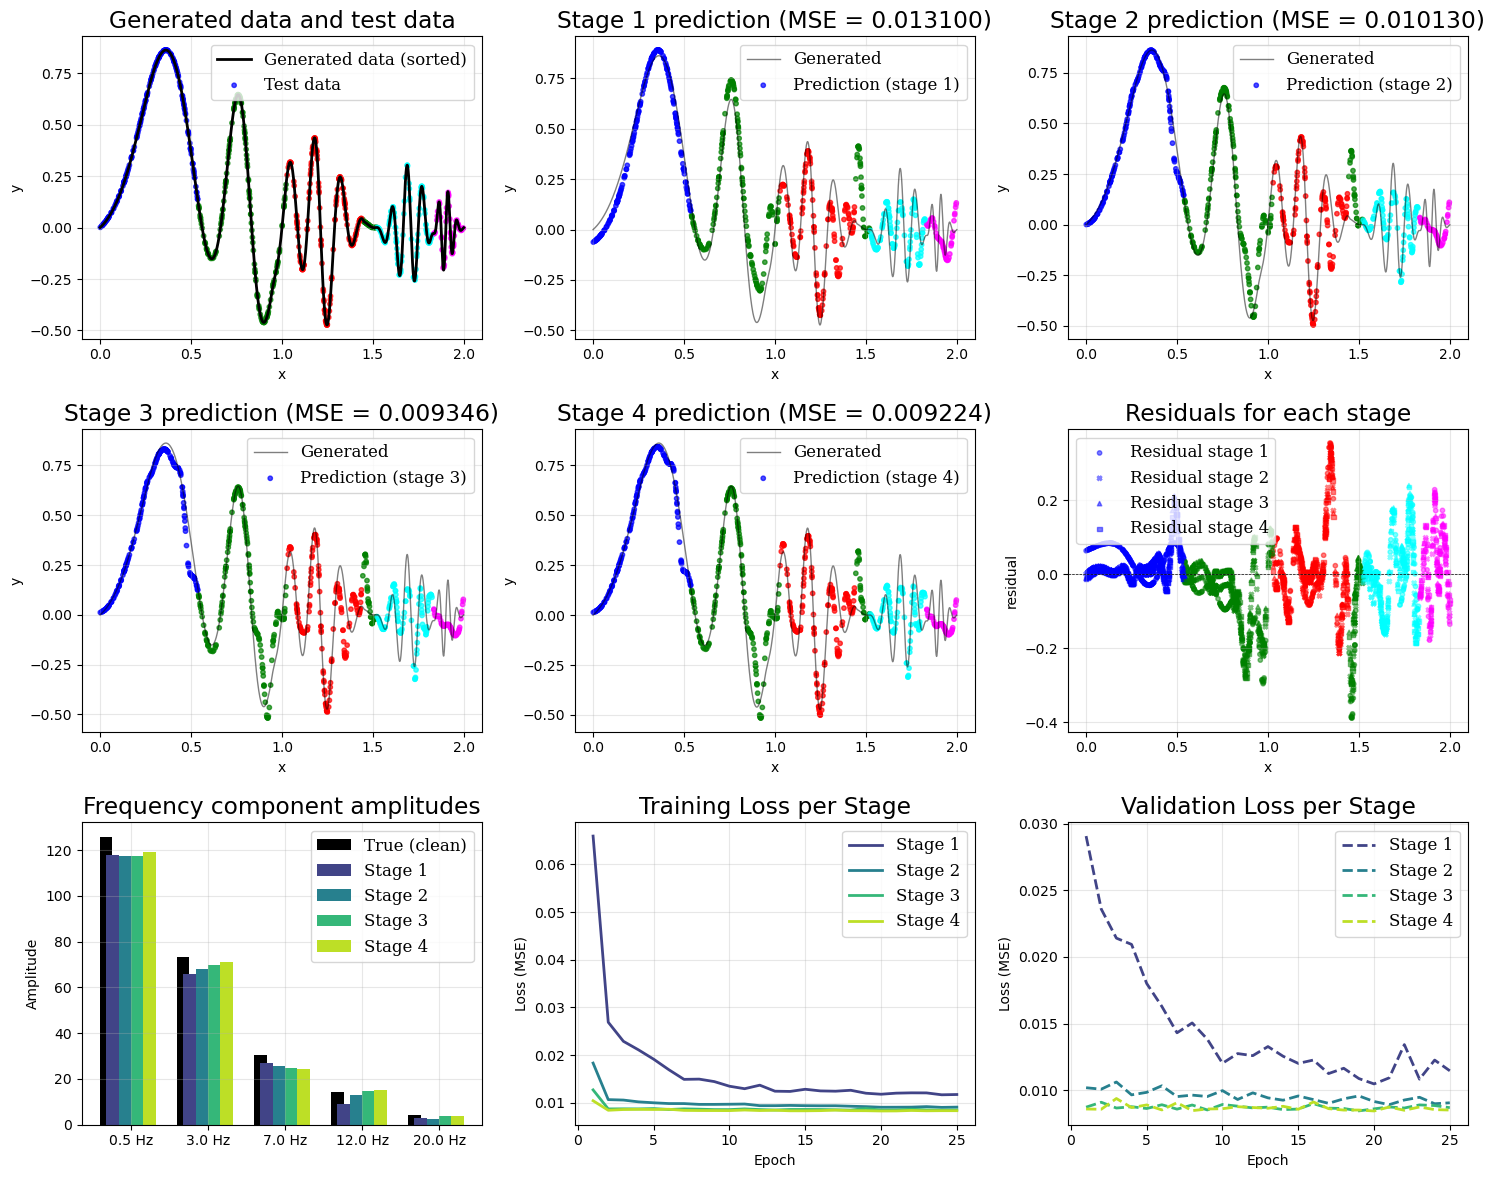

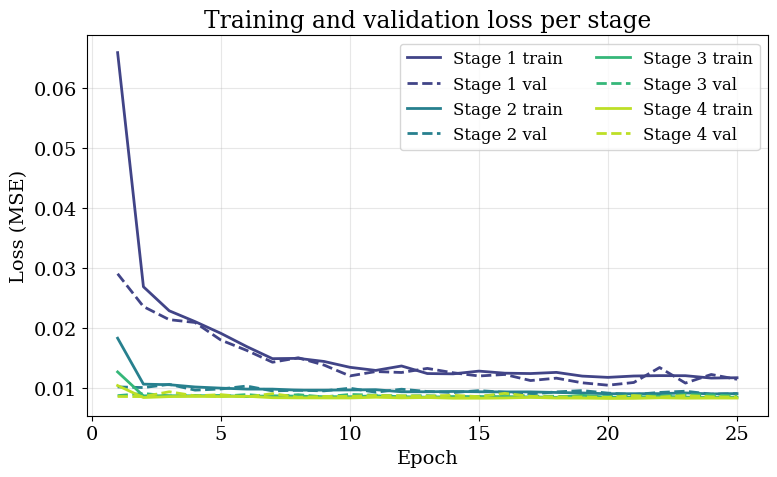

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# --------------------------------------------
# 4. Hybrid Quantum‑Classical Model (fixed for multi‑dim input)
# --------------------------------------------
class QuantumModel(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2, input_dim=1, dev="default.qubit"):
        super().__init__()
        assert input_dim <= n_qubits, "Need at least as many qubits as input features"
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.input_dim = input_dim
        self.dev = qml.device(dev, wires=n_qubits)

        # Correct parameter count per layer: 3 * n_qubits * (n_qubits + 1)
        self.params_per_layer = 3 * n_qubits * (n_qubits + 1)
        total_params = n_layers * self.params_per_layer
        self.circuit_weights = nn.Parameter(0.1 * torch.randn(total_params))

        self.linear = nn.Linear(n_qubits, 1)

        def circuit(inputs, weights):
            # inputs shape: (batch, input_dim)
            # weights shape: (total_params,)

            weights = torch.pi * torch.tanh(weights)  # scale to [-π, π]
            # Initial encoding: each input feature on a separate qubit (RY)
            for q in range(self.n_qubits):
                feat_idx = q % self.input_dim          # cycle through input features
                qml.RY(np.pi * inputs[:, feat_idx], wires=q)
                qml.RZ(np.pi * inputs[:, feat_idx]**3, wires=q)
                qml.RX(np.pi * torch.sqrt(torch.abs(1 - inputs[:, feat_idx]**2)), wires=q)    


            # Variational layers
            idx = 0
            for l in range(self.n_layers):
                # Single‑qubit rotations on all qubits
                for q in range(self.n_qubits):
                    qml.RY(weights[idx], wires=q)
                    idx += 1
                    qml.RZ(weights[idx], wires=q)
                    idx += 1
                    qml.RX(weights[idx], wires=q)
                    idx += 1

                # Entangling layer: all‑to‑all (including self) with controlled rotations
                for q1 in range(self.n_qubits):
                    for q2 in range(self.n_qubits):
                        if q1 != q2:
                            qml.CRY(weights[idx], wires=[q1, q2])
                            idx += 1
                            qml.CRZ(weights[idx], wires=[q1, q2])
                            idx += 1
                            qml.CRX(weights[idx], wires=[q1, q2])
                            idx += 1
                        else:
                            qml.RY(weights[idx], wires=q1)
                            idx += 1
                            qml.RZ(weights[idx], wires=q1)
                            idx += 1
                            qml.RX(weights[idx], wires=q1)
                            idx += 1

            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.circuit = qml.QNode(
            circuit, self.dev, interface="torch", diff_method="backprop"
        )

    def forward(self, x):
        # x shape: (batch, input_dim)
        qubit_expectations = self.circuit(x, self.circuit_weights)
        features = torch.stack(qubit_expectations, dim=1).to(torch.float32)
        out = self.linear(features)
        return out.to(torch.float32)


# --------------------------------------------
# 5. Training helper (unchanged)
# --------------------------------------------
def train_model(model, train_loader, val_loader, epochs=100, lr=0.01, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            total_val_loss = 0.0
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                total_val_loss += loss.item() * X_batch.size(0)
            val_loss = total_val_loss / len(val_loader.dataset)
            val_losses.append(val_loss)

        if verbose == True:
            print(
                f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}"
            )
    return train_losses, val_losses


# --------------------------------------------
# 6. Multi‑Stage Residual Quantum Learner (fixed for multi‑dim input)
# --------------------------------------------
class ResidualQuantumLearner:
    def __init__(
        self, input_dim, n_qubits=4, n_layers=2, lr=0.01, epochs=100, n_stages=2
    ):
        self.input_dim = input_dim
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.lr = lr
        self.epochs = epochs
        self.n_stages = n_stages
        self.models = []
        self.stage_losses = []

    def _cascade_outputs(self, X_batch):
        """Return list of outputs from all trained models, 
        and the final concatenated input.
        """
        outputs = []
        inp = X_batch
        for m in self.models:
            out = m(inp)
            outputs.append(out)
            # For next stage, concatenate original X and the latest prediction
            inp = torch.cat([X_batch, out], dim=1)
        return outputs

    def fit(self, train_loader, val_loader):
        print(f"\n--- Stage 1/{self.n_stages}: Training on original data ---")
        model0 = QuantumModel(self.n_qubits, self.n_layers, input_dim=self.input_dim)
        tr_loss, val_loss = train_model(
            model0, train_loader, val_loader, epochs=self.epochs, lr=self.lr
        )
        self.models.append(model0)
        self.stage_losses.append((tr_loss, val_loss))

        for stage in range(1, self.n_stages):
            print(f"\n--- Stage {stage+1}/{self.n_stages}: Training residual model ---")
            train_inputs, train_targets = [], []
            val_inputs, val_targets = [], []
            with torch.no_grad():
                for X_batch, y_batch in train_loader:
                    outputs = self._cascade_outputs(X_batch)
                    pred_sum = sum(outputs)
                    residual = y_batch - pred_sum
                    next_inp = torch.cat(
                        [X_batch, outputs[-1]], dim=1
                    )  # shape (batch, input_dim+1)
                    train_inputs.append(next_inp)
                    train_targets.append(residual)
                for X_batch, y_batch in val_loader:
                    outputs = self._cascade_outputs(X_batch)
                    pred_sum = sum(outputs)
                    residual = y_batch - pred_sum
                    next_inp = torch.cat([X_batch, outputs[-1]], dim=1)
                    val_inputs.append(next_inp)
                    val_targets.append(residual)

            train_inputs = torch.cat(train_inputs, dim=0)
            train_targets = torch.cat(train_targets, dim=0)
            val_inputs = torch.cat(val_inputs, dim=0)
            val_targets = torch.cat(val_targets, dim=0)

            train_res_dataset = TensorDataset(train_inputs, train_targets)
            val_res_dataset = TensorDataset(val_inputs, val_targets)
            train_res_loader = DataLoader(
                train_res_dataset, batch_size=train_loader.batch_size, shuffle=True
            )
            val_res_loader = DataLoader(
                val_res_dataset, batch_size=val_loader.batch_size, shuffle=False
            )

            # New model takes original input + one extra feature (previous prediction)
            new_model = QuantumModel(
                self.n_qubits, self.n_layers, input_dim=self.input_dim + 1
            )
            tr_loss, val_loss = train_model(
                new_model,
                train_res_loader,
                val_res_loader,
                epochs=self.epochs,
                lr=self.lr,
            )
            self.models.append(new_model)
            self.stage_losses.append((tr_loss, val_loss))

        return self.models, self.stage_losses

    def predict(self, X, stage=None):
        if stage is None:
            stage = len(self.models)
        else:
            stage = min(stage, len(self.models))
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if X.dim() == 1:
            X = X.unsqueeze(0)
        with torch.no_grad():
            inp = X
            outputs = []
            for i, m in enumerate(self.models):
                if i >= stage:
                    break
                out = m(inp)
                outputs.append(out)
                # For next stage (if any), we need the concatenated input
                inp = torch.cat([X, out], dim=1)
            pred = sum(outputs)
        return pred


# --------------------------------------------
# Data generation helpers (unchanged but renamed for clarity)
# --------------------------------------------
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def generate_multifreq_data(
    n_samples=2000,
    x_range=(0, 2),
    noise=0.05,
    components=None,
    envelope_func=None,
    random_state=None,
):
    if random_state is not None:
        np.random.seed(random_state)

    if components is None:
        components = [
            {"freq": 1, "center": 0.5, "width": 0.3, "amp": 1.0},
            {"freq": 2, "center": 1.0, "width": 0.3, "amp": 0.8},
            {"freq": 4, "center": 1.5, "width": 0.3, "amp": 0.6},
        ]

    if envelope_func is None:

        def envelope_func(x, center, width):
            return np.exp(-(((x - center) / width) ** 2))

    x = np.random.uniform(*x_range, n_samples).astype(np.float32)
    y = np.zeros(n_samples, dtype=np.float32)

    for comp in components:
        freq = comp["freq"]
        center = comp["center"]
        width = comp["width"]
        amp = comp.get("amp", 1.0)
        env = comp.get("envelope", envelope_func)
        weights = env(x, center, width).astype(np.float32)
        y += amp * weights * np.sin(2 * np.pi * freq * x)

    y += noise * np.random.randn(n_samples)
    return x.reshape(-1, 1), y.reshape(-1, 1)


def load_data(X, y, batch_size=64, val_split=0.15, test_split=0.15):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=val_split + test_split, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_split / (val_split + test_split), random_state=42
    )
    train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
    test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, X, y


def generate_clean_grid(components, x_range, n_points=1000, envelope_func=None):
    x_grid = np.linspace(x_range[0], x_range[1], n_points)
    y_clean = np.zeros(n_points, dtype=np.float32)

    if envelope_func is None:

        def envelope_func(x, center, width):
            return np.exp(-(((x - center) / width) ** 2))

    for comp in components:
        freq = comp["freq"]
        center = comp["center"]
        width = comp["width"]
        amp = comp.get("amp", 1.0)
        env = comp.get("envelope", envelope_func)
        weights = env(x_grid, center, width)
        y_clean += amp * weights * np.sin(2 * np.pi * freq * x_grid)
    return x_grid, y_clean


def compute_frequency_amplitudes(components, x_range, n_stages, learner, n_points=1000):
    x_grid, y_clean = generate_clean_grid(components, x_range, n_points)
    dx = x_grid[1] - x_grid[0]
    fft_true = np.abs(np.fft.fft(y_clean)[: n_points // 2])
    freqs = np.fft.fftfreq(n_points, d=dx)[: n_points // 2]

    grid_preds = []
    for stage in range(1, n_stages + 1):
        pred = learner.predict(
            torch.tensor(x_grid.reshape(-1, 1), dtype=torch.float32), stage=stage
        )
        grid_preds.append(pred.numpy().flatten())

    fft_stages = [np.abs(np.fft.fft(p)[: n_points // 2]) for p in grid_preds]

    target_freqs = sorted(list({comp["freq"] for comp in components}))
    idxs = [np.argmin(np.abs(freqs - f)) for f in target_freqs]

    amps_true = [fft_true[i] for i in idxs]
    amps_stages = [[fft[i] for i in idxs] for fft in fft_stages]

    return target_freqs, amps_true, amps_stages


def get_region_colors(X, components, default_envelope_func=None):
    x = np.asarray(X).flatten()
    n_components = len(components)
    if default_envelope_func is None:

        def default_envelope_func(x, center, width):
            return np.exp(-(((x - center) / width) ** 2))

    envelopes = np.zeros((len(x), n_components))
    for i, comp in enumerate(components):
        center = comp["center"]
        width = comp["width"]
        env_func = comp.get("envelope", default_envelope_func)
        envelopes[:, i] = env_func(x, center, width)

    dominant_idx = np.argmax(envelopes, axis=1)
    color_list = [
        "blue",
        "green",
        "red",
        "cyan",
        "magenta",
        "yellow",
        "orange",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "teal",
    ]
    if n_components > len(color_list):
        color_list = color_list * (n_components // len(color_list) + 1)
    color_map = {i: color_list[i] for i in range(n_components)}
    return [color_map[i] for i in dominant_idx]

    # --------------------------------------------
    # Main script (using config)
    # --------------------------------------------


if __name__ == "__main__":

    # =============================================================================
    # CONFIGURATION DICTIONARY – CHANGE PARAMETERS HERE
    # =============================================================================
    config = {
        "seed": 42,
        "data": {
            "n_samples": 5000,
            "x_range": (0, 2.0),
            "noise": 0.0,
            "components": [
                {"freq": 0.5, "center": 0.3, "width": 0.2, "amp": 1.0},
                {
                    "freq": 3.0,
                    "center": 0.8,
                    "width": 0.15,
                    "amp": 0.7,
                    "envelope": lambda x, c, w: 1 / (1 + ((x - c) / w) ** 2),
                },  # Lorentzian
                {
                    "freq": 7.0,
                    "center": 1.2,
                    "width": 0.25,
                    "amp": 0.5,
                    "envelope": lambda x, c, w: np.maximum(0, 1 - np.abs(x - c) / w),
                },  # triangular
                {"freq": 12.0, "center": 1.7, "width": 0.1, "amp": 0.3},
                {"freq": 20.0, "center": 1.9, "width": 0.05, "amp": 0.2},
            ],
        },
        "training": {
            "batch_size": 64,
            "val_split": 0.15,
            "test_split": 0.15,
        },
        "model": {
            "input_dim": 1,  # will be increased automatically for residual stages
            "n_qubits": 8,
            "n_layers": 2,
        },
        "optim": {
            "lr": 0.005,
            "epochs": 25,
        },
        "residual": {
            "n_stages": 4,
        },
    }
    # =============================================================================

    set_seed(config["seed"])

    # Data generation
    X, y = generate_multifreq_data(
        n_samples=config["data"]["n_samples"],
        x_range=config["data"]["x_range"],
        noise=config["data"]["noise"],
        components=config["data"]["components"],
        random_state=config["seed"],
    )

    train_loader, val_loader, test_loader, X_all, y_all = load_data(
        X,
        y,
        batch_size=config["training"]["batch_size"],
        val_split=config["training"]["val_split"],
        test_split=config["training"]["test_split"],
    )

    # Model creation and training
    learner = ResidualQuantumLearner(
        input_dim=config["model"]["input_dim"],
        n_qubits=config["model"]["n_qubits"],
        n_layers=config["model"]["n_layers"],
        lr=config["optim"]["lr"],
        epochs=config["optim"]["epochs"],
        n_stages=config["residual"]["n_stages"],
    )

    models, losses = learner.fit(train_loader, val_loader)

    # Test set evaluation
    X_test_t = test_loader.dataset.tensors[0]
    y_test_t = test_loader.dataset.tensors[1]
    X_test = X_test_t.numpy()
    y_test = y_test_t.numpy()

    n_stages = learner.n_stages
    predictions = []
    mse_list = []

    for stage in range(1, n_stages + 1):
        pred = learner.predict(X_test_t, stage=stage).numpy()
        predictions.append(pred)
        mse = np.mean((pred - y_test) ** 2)
        mse_list.append(mse)
        print(f"Test MSE (stage {stage}): {mse:.6f}")

    # Region colors
    colors = get_region_colors(X_test, config["data"]["components"])

    # Sorted full data for a smooth line
    sort_idx = np.argsort(X.flatten())
    X_sorted = X[sort_idx].flatten()
    y_sorted = y[sort_idx].flatten()

    # Dynamic plotting
    n_plots = n_stages + 3
    ncols = min(3, n_plots)  # at most 3 columns for readability
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    plt.rcParams['font.size'] = 14
    plt.rcParams['lines.linewidth'] = 2
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.titlesize'] = 14
    plt.rcParams['font.family'] = 'serif'
    axes = axes.flatten()

    # 1. True data and test points
    ax = axes[0]
    ax.plot(X_sorted, y_sorted, "k-", linewidth=2, label="Generated data (sorted)")
    ax.scatter(X_test, y_test, c=colors, s=10, alpha=0.7, label="Test data")
    ax.set_title("Generated data and test data")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Stage predictions
    for i, pred in enumerate(predictions):
        ax = axes[1 + i]
        ax.plot(X_sorted, y_sorted, "k-", linewidth=1, alpha=0.5, label="Generated")
        ax.scatter(
            X_test, pred, c=colors, s=10, alpha=0.7, label=f"Prediction (stage {i+1})"
        )
        ax.set_title(f"Stage {i+1} prediction (MSE = {mse_list[i]:.6f})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 3. Residuals
    ax = axes[1 + n_stages]
    markers = ["o", "x", "^", "s", "D", "v", "<", ">", "p", "*"]
    for i, pred in enumerate(predictions):
        marker = markers[i % len(markers)]
        ax.scatter(
            X_test,
            y_test - pred,
            c=colors,
            s=10,
            alpha=0.5,
            marker=marker,
            label=f"Residual stage {i+1}",
        )
    ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    ax.set_title("Residuals for each stage")
    ax.set_xlabel("x")
    ax.set_ylabel("residual")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Frequency component amplitudes
    ax = axes[2 + n_stages]
    target_freqs, amps_true, amps_stages = compute_frequency_amplitudes(
        components=config["data"]["components"],
        x_range=config["data"]["x_range"],
        n_stages=n_stages,
        learner=learner,
        n_points=1000,
    )

    x_pos = np.arange(len(target_freqs))
    width = 0.8 / (n_stages + 1)

    # True signal bar
    ax.bar(
        x_pos - (n_stages * width / 2),
        amps_true,
        width,
        label="True (clean)",
        color="black",
        align="center",
    )

    # Bars for each stage
    stage_colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_stages))
    for i, amps in enumerate(amps_stages):
        offset = (i - (n_stages - 1) / 2) * width
        ax.bar(
            x_pos + offset,
            amps,
            width,
            label=f"Stage {i+1}",
            color=stage_colors[i],
            align="center",
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{f:.1f} Hz" for f in target_freqs])
    ax.set_ylabel("Amplitude")
    ax.set_title("Frequency component amplitudes")
    ax.legend()
    ax.grid(True, alpha=0.3)
    # ... after frequency amplitude plot ...

    # -------------------------------------------------
    # Place training/validation loss curves in empty slots
    # -------------------------------------------------
    # Determine empty indices (those not used by main plots)
    used_indices = set(range(n_plots))  # main plots occupy indices 0..n_plots-1
    all_indices = set(range(len(axes)))
    empty_indices = sorted(all_indices - used_indices)

    if len(empty_indices) >= 2:
        # Use the last two empty slots for train and val curves
        ax_train = axes[empty_indices[-2]]
        ax_val   = axes[empty_indices[-1]]

        stage_colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_stages))
        for i, (train_losses, val_losses) in enumerate(learner.stage_losses):
            epochs = range(1, len(train_losses) + 1)
            ax_train.plot(epochs, train_losses, color=stage_colors[i],
                        linestyle='-', label=f'Stage {i+1}')
            ax_val.plot(epochs, val_losses, color=stage_colors[i],
                        linestyle='--', label=f'Stage {i+1}')

        ax_train.set_xlabel('Epoch')
        ax_train.set_ylabel('Loss (MSE)')
        ax_train.set_title('Training Loss per Stage')
        ax_train.legend()
        ax_train.grid(True, alpha=0.3)

        ax_val.set_xlabel('Epoch')
        ax_val.set_ylabel('Loss (MSE)')
        ax_val.set_title('Validation Loss per Stage')
        ax_val.legend()
        ax_val.grid(True, alpha=0.3)

        # Mark these slots as used so they aren't hidden later
        used_indices.update([empty_indices[-2], empty_indices[-1]])
    else:
        print("Warning: Not enough empty slots for loss curves; keeping separate figure.")
        # Optionally still create the separate figure here
    # Hide unused subplots
    # Hide any remaining unused subplots
    for j in range(len(axes)):
        if j not in used_indices:
            axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"residual_learning_results-qubits{config['model']['n_qubits']}.png", dpi=300)
    plt.savefig(f"residual_learning_results-qubits{config['model']['n_qubits']}.pdf", dpi=300)
    plt.show()

    # # 3. Residuals for each stage (colored by region, no overlapping markers)
    # for i, pred in enumerate(predictions):
    #     ax = axes1[plot_idx]; plot_idx += 1
    #     residual = (y_test - pred).flatten()
    #     ax.scatter(X_test, residual, c=colors, s=10, alpha=0.7)
    #     ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
    #     ax.set_title(f'Residuals stage {i+1}')
    #     ax.set_xlabel('x')
    #     ax.set_ylabel('residual')
    #     ax.grid(True, alpha=0.3)

    # -------------------------------------------------
    # Figure 2: Train/validation loss curves for all stages
    # -------------------------------------------------
    fig2, ax_loss = plt.subplots(1, 1, figsize=(8, 5))

    plt.rcParams['font.size'] = 14
    plt.rcParams['lines.linewidth'] = 2
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.titlesize'] = 14
    plt.rcParams['font.family'] = 'serif'
    stage_colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_stages))
    for i, (train_losses, val_losses) in enumerate(learner.stage_losses):
        epochs = range(1, len(train_losses) + 1)
        ax_loss.plot(
            epochs,
            train_losses,
            color=stage_colors[i],
            linestyle="-",
            label=f"Stage {i+1} train",
        )
        ax_loss.plot(
            epochs,
            val_losses,
            color=stage_colors[i],
            linestyle="--",
            label=f"Stage {i+1} val",
        )
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss (MSE)")
    ax_loss.set_title("Training and validation loss per stage")
    ax_loss.legend(ncol=2)
    ax_loss.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"training_curves-qubits{config['model']['n_qubits']}.png", dpi=300)
    plt.savefig(f"training_curves-qubits{config['model']['n_qubits']}.pdf", dpi=300)
    plt.show()